# Starter Pipeline — Transit Detection in Kepler Photometry

This notebook runs **end to end**: it loads a light curve, cleans it, searches for a
periodic transit signal, and writes a valid submission file.

It is deliberately simple. It is a **floor to beat, not a solution to tweak.**
Every stage below is the most obvious thing that works, and every stage can be
improved substantially. Your job is to replace them.

## The pipeline

```
raw SAP flux
  -> mask bad cadences        (quality flags)
  -> normalise per quarter    (remove inter-quarter jumps)
  -> detrend                  (remove stellar variability + drift)
  -> BLS period search        (find the transit)
  -> threshold + report       (decide, and measure)
```

## Read this before you start

**A naive period grid will find nothing.** This is the single biggest trap in
this problem. A full-resolution BLS search to 400 days needs ~14 million trial
periods — roughly 5 hours *per star*. If you instead use a coarse fixed grid,
your trial periods land too far from the true one, the fold smears the transit
away, and you detect nothing at all — even for signals that are obvious by eye.

The pipeline below uses a **coarse-to-fine** search: a wide cheap sweep to
localise candidates, then a fine sweep around each peak. That makes the search
tractable. Understand this part before changing it.

**Develop on a handful of stars.** Run the full set only when you have something
worth testing.

In [3]:
%pip install -q astropy pyarrow pandas numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [4]:
%pip install matplotlib pandas numpy astropy


Note: you may need to restart the kernel to use updated packages.


In [1]:
%pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.


In [12]:
import glob
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.timeseries import BoxLeastSquares

warnings.filterwarnings("ignore")

# point these at wherever you unzipped the packs
TRAIN_DIR = "./train_pack/train"
DEV_DIR = "./dev_pack/dev"
#PRIVATE_DIR = "private"

print("train  ", len(glob.glob(f"{TRAIN_DIR}/*.parquet")), "stars")
print("dev    ", len(glob.glob(f"{DEV_DIR}/*.parquet")), "stars")
#print("private", len(glob.glob(f"{PRIVATE_DIR}/*.parquet")), "stars")

train   269 stars
dev     89 stars


## 1. What a light curve looks like

Each file is a single star's brightness over ~4 years, sampled every 29.4 minutes.

| column | meaning |
|---|---|
| `time` | days |
| `flux` | raw SAP flux — **not** detrended |
| `flux_err` | uncertainty per measurement |
| `quality` | bitmask; 0 means good |
| `quarter` | which ~90-day observing quarter |

The flux is **raw**. Removing instrumental and stellar signals without destroying
the transit is a core part of the problem, not a preprocessing detail.

In [13]:
files = sorted(glob.glob(f"{TRAIN_DIR}/*.parquet"))
if not files:
    raise FileNotFoundError(f"No parquet files were found in '{TRAIN_DIR}'. Check that the training data folder exists and contains .parquet files.")
df = pd.read_parquet(files[0])

print(df.shape)
print(df.head())
print(f"\nbaseline: {df.time.max() - df.time.min():.0f} days")
print(f"quarters: {sorted(df.quarter.unique())}")
print(f"bad cadences: {(df.quality != 0).mean():.1%}")

(65031, 5)
         time          flux  flux_err  quality  quarter
0  131.512362  25258.015625  4.912865        0        1
1  131.532796  25253.623047  4.911165        0        1
2  131.553230  25249.341797  4.910938        0        1
3  131.573664  25258.361328  4.911520        0        1
4  131.594099  25256.476562  4.911935        0        1

baseline: 1459 days
quarters: [np.int16(1), np.int16(2), np.int16(3), np.int16(4), np.int16(5), np.int16(6), np.int16(7), np.int16(8), np.int16(9), np.int16(10), np.int16(11), np.int16(12), np.int16(13), np.int16(14), np.int16(15), np.int16(16), np.int16(17)]
bad cadences: 10.0%


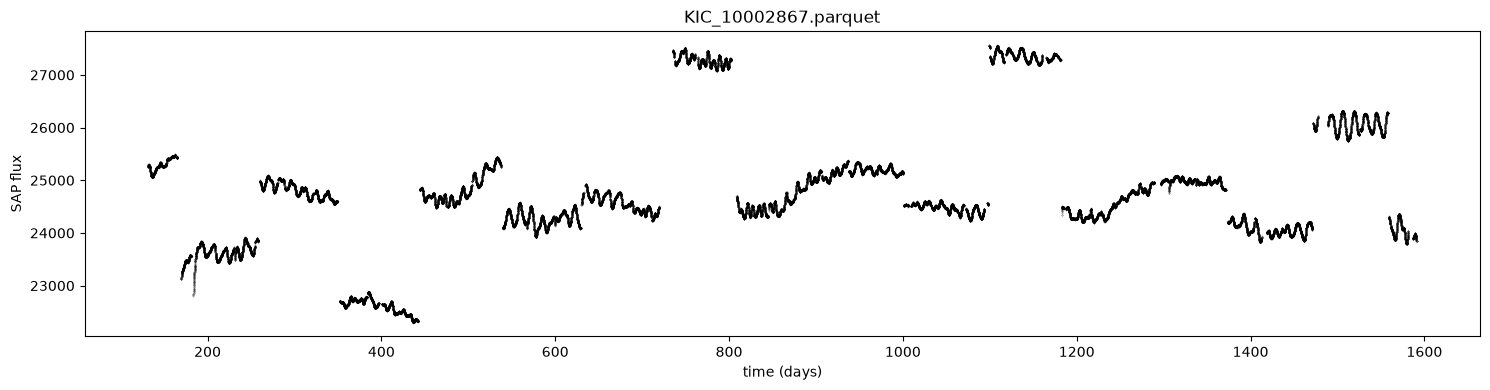

In [14]:
fig, ax = plt.subplots(figsize=(15, 4))
m = df.quality == 0
ax.plot(df.time[m], df.flux[m], "k.", ms=0.5, alpha=0.5)
ax.set_xlabel("time (days)")
ax.set_ylabel("SAP flux")
ax.set_title(os.path.basename(files[0]))
plt.tight_layout()
plt.show()

# The step changes are quarter boundaries: the spacecraft rolled every ~90 days,
# putting the star on a different detector. The slow wiggles within a quarter are
# a mix of stellar variability and instrumental drift. A transit is a dip of
# 0.01%-0.2% lasting a few hours. You cannot see it here. That is the problem.

## 2. Cleaning

Three steps, each of which you should question:

**Quality mask.** Drop cadences flagged by the mission — cosmic rays, thruster
firings, safe-mode recovery. Dropping everything non-zero is blunt; the bits mean
different things and some are harmless.

**Per-quarter normalisation.** Divide each quarter by its median to remove the
jumps. Crude: it assumes flux within a quarter is stationary, which it is not.

**Detrending.** Divide by a running median. The window length is the critical
parameter — too long and variability survives, too short and you eat the transit
itself. A 1-day window is safe for transits lasting a few hours, and wrong for
long-duration transits of long-period planets.

Better approaches exist: spline or Savitzky-Golay filtering, Gaussian processes,
PCA against other stars, iterative masking of in-transit points. This is
the highest-leverage part of the pipeline — in testing, proper detrending took
recovered transit depth from 33% of true to 90%.

58500 cadences, scatter 292 ppm


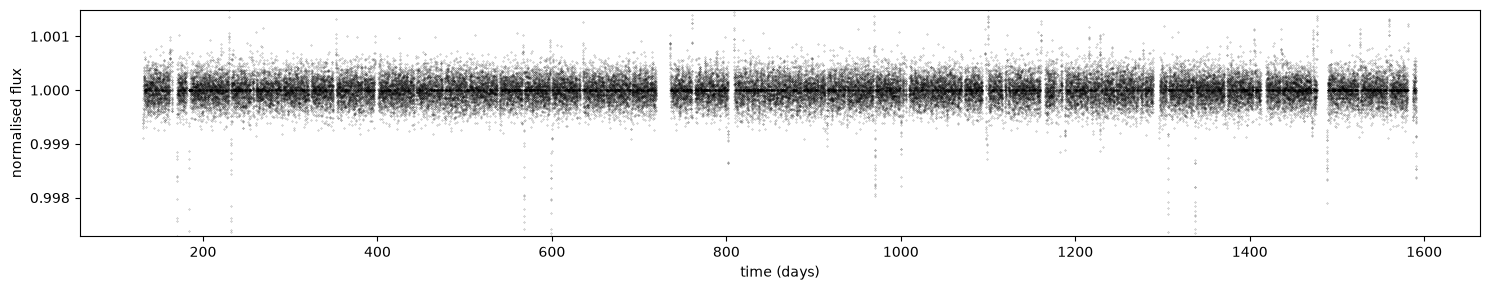

In [15]:
DETREND_WINDOW_DAYS = 1.0


def clean(df, window_days=DETREND_WINDOW_DAYS):
    """Raw light curve -> (time, normalised flux) ready for a period search."""
    m = (df.quality.values == 0) & np.isfinite(df.flux.values)
    t = df.time.values[m]
    f = df.flux.values[m].astype(float)
    q = df.quarter.values[m]
    if len(t) < 1000:
        return None, None

    # normalise each quarter to its own median
    for qq in np.unique(q):
        s = q == qq
        med = np.median(f[s])
        f[s] = f[s] / med if med > 0 else 1.0

    # centred running median as the trend estimate
    cadence = np.median(np.diff(t))
    k = max(5, int(window_days / cadence) | 1)  # odd window
    trend = pd.Series(f).rolling(k, center=True, min_periods=k // 3).median().values

    ok = np.isfinite(trend) & (trend > 0)
    return t[ok], f[ok] / trend[ok]


t, f = clean(df)
print(f"{len(t)} cadences, scatter {np.std(f) * 1e6:.0f} ppm")

fig, ax = plt.subplots(figsize=(15, 3))
ax.plot(t, f, "k.", ms=0.5, alpha=0.5)
ax.set_ylim(np.percentile(f, 0.1), np.percentile(f, 99.9))
ax.set_xlabel("time (days)")
ax.set_ylabel("normalised flux")
plt.tight_layout()
plt.show()

# Compare that scatter to the transit depths you are hunting: 100-2000 ppm.
# The shallowest signals are well below the per-point noise. They only emerge
# once you fold many transits together at the correct period.

## 3. The period search

Box Least Squares folds the light curve at many trial periods and looks for a
box-shaped dip.

**Why the grid matters so much.** To keep a transit aligned across the whole
4-year baseline, a trial period must be accurate to roughly
`duration / n_transits`. For a 3-hour transit at 35 days, that is about
0.003 days. A 3000-point grid spanning 3–400 days gives spacing of ~0.04 days
near 35 days — more than ten times too coarse. Every trial misses, the folded
transit smears across phase, and the signal vanishes.

The required resolution scales as roughly `P^2 / (baseline x duration)`, so the
cost of a complete search grows steeply with maximum period. Searching to 400
days at full resolution is ~14 million trials.

**Coarse-to-fine.** Sweep a cheap grid to find regions with elevated power, then
re-search finely only around those peaks. Roughly 100x cheaper for most of the
sensitivity. This is what the function below does, and it is the part worth
understanding before you change anything else.

In [16]:
PERIOD_MIN = 3.0
PERIOD_MAX = 400.0
N_COARSE = 20000       # raise for better sensitivity, at linear cost
N_PEAKS = 8            # how many coarse peaks to refine
N_FINE = 600           # trials per refinement window
DURATIONS = np.array([0.05, 0.1, 0.2, 0.4, 0.8])  # days


def sde(power, i):
    """Signal Detection Efficiency: peak height above the periodogram floor,
    in robust standard deviations. MAD is used so a strong peak does not
    inflate its own noise estimate."""
    med = np.nanmedian(power)
    mad = np.nanmedian(np.abs(power - med))
    return float((power[i] - med) / (1.4826 * mad)) if mad > 0 else 0.0


def search(t, f, verbose=False):
    """Coarse-to-fine BLS. Returns the best candidate."""
    bls = BoxLeastSquares(t, f)
    baseline = t.max() - t.min()
    pmax = min(PERIOD_MAX, baseline / 3.0)   # insist on >= 3 transits

    # --- coarse sweep, log-spaced ---
    coarse = np.exp(np.linspace(np.log(PERIOD_MIN), np.log(pmax), N_COARSE))
    res = bls.power(coarse, DURATIONS, objective="likelihood")
    power = np.asarray(res.power)

    # --- pick well-separated peaks ---
    order = np.argsort(power)[::-1]
    peaks, used = [], np.zeros(len(coarse), bool)
    for i in order:
        if used[i]:
            continue
        peaks.append(i)
        lo = np.searchsorted(coarse, coarse[i] * 0.9)
        hi = np.searchsorted(coarse, coarse[i] * 1.1)
        used[lo:hi] = True
        if len(peaks) >= N_PEAKS:
            break

    # --- refine around each peak ---
    best = None
    for i in peaks:
        p0 = coarse[i]
        width = 0.02 * p0                         # +/- 2%
        fine = np.linspace(p0 - width, p0 + width, N_FINE)
        fine = fine[fine > PERIOD_MIN]
        if len(fine) < 10:
            continue

        r = bls.power(fine, DURATIONS, objective="likelihood")
        p = np.asarray(r.power)
        j = int(np.nanargmax(p))
        score = sde(power, i)                     # rank on the coarse periodogram

        if best is None or score > best["sde"]:
            best = {
                "period": float(r.period[j]),
                "depth_ppm": float(r.depth[j] * 1e6),
                "duration_hours": float(r.duration[j] * 24),
                "t0": float(r.transit_time[j]),
                "sde": score,
            }
        if verbose:
            print(f"  peak P={p0:8.3f} -> refined {r.period[j]:8.4f}  SDE {score:5.1f}")

    return best or {"period": np.nan, "depth_ppm": np.nan,
                    "duration_hours": np.nan, "t0": np.nan, "sde": 0.0}

## 4. Does it work?

`train_truth.csv` lists the injected signals with their true parameters. Take the
deepest one and check the pipeline recovers it. **Always verify on a known signal
before trusting a null result on unknown data** — if we had not done this, we
would have concluded the data was empty when the search grid was simply wrong.

In [18]:
truth = pd.read_csv("./train_pack/train_truth.csv")
row = truth[truth.injected == 1].sort_values("depth_ppm", ascending=False).iloc[0]

print(f"KIC {int(row.kepid)}")
print(f"  true period   {row.period_days:.4f} d")
print(f"  true depth    {row.depth_ppm:.0f} ppm")
print(f"  true duration {row.duration_hours:.2f} h")
print(f"  transits      {int(row.n_transits)}\n")

t, f = clean(pd.read_parquet(f"{TRAIN_DIR}/KIC_{int(row.kepid)}.parquet"))
found = search(t, f, verbose=True)

err = abs(found["period"] - row.period_days) / row.period_days
print(f"\nrecovered  P={found['period']:.4f} d  ({err:.2%} error)")
print(f"           depth={found['depth_ppm']:.0f} ppm  SDE={found['sde']:.1f}")

KIC 4935189
  true period   9.3204 d
  true depth    1977 ppm
  true duration 3.83 h
  transits      118

  peak P= 325.693 -> refined 325.7254  SDE  25.5
  peak P= 372.695 -> refined 372.6324  SDE  18.8
  peak P= 217.783 -> refined 217.7753  SDE  13.4
  peak P= 181.584 -> refined 181.5901  SDE  10.7
  peak P= 290.315 -> refined 290.3247  SDE  10.3
  peak P= 145.199 -> refined 145.1843  SDE  10.0
  peak P= 245.640 -> refined 245.6155  SDE   9.1
  peak P= 162.853 -> refined 162.8366  SDE   7.8

recovered  P=325.7254 d  (3394.74% error)
           depth=7726 ppm  SDE=25.5


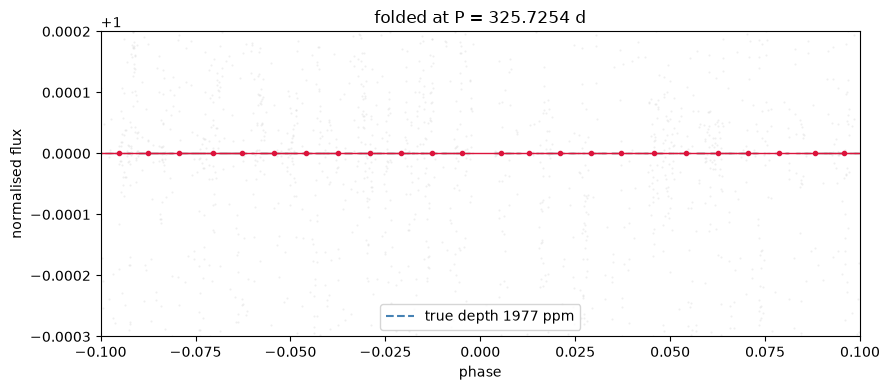

In [19]:
def plot_folded(t, f, period, t0, depth_ppm=None, bins=120):
    """Fold on a period and bin. If the period is right, a dip appears at 0."""
    ph = ((t - t0) / period) % 1.0
    ph = np.where(ph > 0.5, ph - 1, ph)
    o = np.argsort(ph)
    ph, ff = ph[o], f[o]

    edges = np.linspace(-0.5, 0.5, bins + 1)
    idx = np.digitize(ph, edges) - 1
    bx = np.array([np.median(ph[idx == i]) if (idx == i).sum() else np.nan
                   for i in range(bins)])
    by = np.array([np.median(ff[idx == i]) if (idx == i).sum() else np.nan
                   for i in range(bins)])

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(ph, ff, ".", color="0.8", ms=1, alpha=0.3)
    ax.plot(bx, by, "o-", color="crimson", ms=3, lw=1)
    if depth_ppm:
        ax.axhline(1 - depth_ppm / 1e6, ls="--", color="steelblue",
                   label=f"true depth {depth_ppm:.0f} ppm")
        ax.legend()
    ax.set_xlim(-0.1, 0.1)
    ax.set_ylim(np.nanpercentile(by, 0) - 3e-4, np.nanpercentile(by, 100) + 2e-4)
    ax.set_xlabel("phase")
    ax.set_ylabel("normalised flux")
    ax.set_title(f"folded at P = {period:.4f} d")
    plt.tight_layout()
    plt.show()


plot_folded(t, f, found["period"], found["t0"], row.depth_ppm)

# Try folding on a deliberately wrong period, e.g. found["period"] * 1.01.
# The dip disappears completely. That is how sharp the grid requirement is.

## 5. Calibrating the threshold

SDE alone does not tell you whether a planet is present. You need to know what
SDE the *empty* stars reach — that is your noise floor, and anything below it is
not a detection.

Run the search over a sample of dev stars, then compare the SDE distribution of
known-empty stars against known-planet stars. Where they overlap is where you
lose points, and narrowing that overlap is most of the work.

In [21]:
N_SAMPLE = 20  # raise once you trust your pipeline

dev_files = sorted(glob.glob(f"{DEV_DIR}/*.parquet"))[:N_SAMPLE]
rows = []
for i, path in enumerate(dev_files, 1):
    t, f = clean(pd.read_parquet(path))
    r = {"star_id": os.path.basename(path)[:-8]} if t is None else \
        {**search(t, f), "star_id": os.path.basename(path)[:-8]}
    rows.append(r)
    print(f"  [{i}/{len(dev_files)}] {r['star_id']} SDE {r.get('sde', 0):.1f}", flush=True)

dev = pd.DataFrame(rows)

# attach ground truth
labels = pd.read_csv("./dev_pack/dev_labels.csv")
dtruth = pd.read_csv("./dev_pack/dev_truth.csv")
dev["kepid"] = dev.star_id.str.replace("KIC_", "").astype(int)
dev = dev.merge(labels[["kepid", "label"]], on="kepid", how="left")
dev = dev.merge(dtruth[["kepid", "injected", "bin", "period_days", "depth_ppm"]],
                on="kepid", how="left", suffixes=("", "_true"))
dev["injected"] = dev.injected.fillna(0)
dev["has_planet"] = ((dev.label == 1) | (dev.injected == 1)).astype(int)

print("\nSDE by truth:")
print(dev.groupby("has_planet").sde.describe()[["count", "50%", "max"]])

  [1/20] KIC_10064054 SDE 17.3
  [2/20] KIC_10262466 SDE 34.6
  [3/20] KIC_10294348 SDE 20.7
  [4/20] KIC_10319385 SDE 35.7
  [5/20] KIC_10385347 SDE 21.6
  [6/20] KIC_10406892 SDE 34.1
  [7/20] KIC_10453542 SDE 23.3
  [8/20] KIC_10717220 SDE 31.2
  [9/20] KIC_10718455 SDE 23.4
  [10/20] KIC_10919052 SDE 19.0
  [11/20] KIC_10928172 SDE 25.9
  [12/20] KIC_11068968 SDE 26.9
  [13/20] KIC_11253711 SDE 20.1
  [14/20] KIC_11457664 SDE 22.8
  [15/20] KIC_11496543 SDE 29.6
  [16/20] KIC_11751454 SDE 18.2
  [17/20] KIC_11773331 SDE 29.6
  [18/20] KIC_11774991 SDE 22.5
  [19/20] KIC_11804465 SDE 1227.4
  [20/20] KIC_11870928 SDE 27.4

SDE by truth:
            count        50%          max
has_planet                               
0             7.0  27.435201    34.647749
1            13.0  23.304056  1227.368840


In [22]:
empty = dev[dev.has_planet == 0].sde
planet = dev[dev.has_planet == 1].sde

print(f"{'SDE':>6} {'recall':>8} {'false pos':>10}")
print("-" * 26)
for thr in (6, 8, 10, 12, 15, 20):
    print(f"{thr:>6} {(planet > thr).mean():>8.0%} {(empty > thr).mean():>10.0%}")

# Pick the threshold that suits your strategy. Precision and recall are both
# scored, so neither extreme wins. Note that a single global cut is itself a
# weak choice -- SDE depends on stellar brightness and variability, so a
# per-star threshold, or a classifier over several features, will do better.
SDE_THRESHOLD = 10.0

   SDE   recall  false pos
--------------------------
     6     100%       100%
     8     100%       100%
    10     100%       100%
    12     100%       100%
    15     100%       100%
    20      85%        86%


## 6. Writing a submission

The `confidence` column drives the ranking metrics and is worth as much as the
hard `prediction`. Mapping SDE through a logistic is the laziest thing that
works; a properly calibrated probability will score better.

Timing note: the cell below runs the full private set. Time a few stars first
and multiply — do not start this at hour 70.

In [23]:
def confidence_from_sde(s, midpoint=SDE_THRESHOLD, steepness=0.4):
    """Squash SDE into (0, 1). Replace with something calibrated."""
    return float(1.0 / (1.0 + np.exp(-steepness * (s - midpoint))))


def run_split(directory):
    out = []
    paths = sorted(glob.glob(f"{directory}/*.parquet"))
    for i, path in enumerate(paths, 1):
        sid = os.path.basename(path)[:-8]
        try:
            t, f = clean(pd.read_parquet(path))
            r = search(t, f) if t is not None else {"sde": 0.0}
        except Exception as e:
            print(f"  {sid} failed: {e}")
            r = {"sde": 0.0}

        s = r.get("sde", 0.0)
        hit = s > SDE_THRESHOLD
        out.append({
            "star_id": sid,
            "prediction": int(hit),
            "confidence": round(confidence_from_sde(s), 4),
            "period": round(r["period"], 5) if hit else None,
            "depth_ppm": round(r["depth_ppm"], 1) if hit else None,
            "duration_hours": round(r["duration_hours"], 3) if hit else None,
        })
        if i % 10 == 0:
            print(f"  [{i}/{len(paths)}]", flush=True)
    return pd.DataFrame(out)


sub = run_split(PRIVATE_DIR)
sub.to_csv("submission.csv", index=False)
print(f"\n{len(sub)} rows, {sub.prediction.sum()} detections")
sub.head()

NameError: name 'PRIVATE_DIR' is not defined

In [ ]:
# Validate before submitting. Fix anything this prints.
s = pd.read_csv("submission.csv")
need = ["star_id", "prediction", "confidence", "period", "depth_ppm", "duration_hours"]

assert list(s.columns) == need, f"columns must be exactly {need}"
assert len(s) == 87, f"expected 87 rows, got {len(s)}"
assert s.star_id.nunique() == 87, "duplicate star_id"
assert s.star_id.str.match(r"^STAR_\d{4}$").all(), "bad star_id format"
assert s.prediction.isin([0, 1]).all(), "prediction must be 0 or 1"
assert s.confidence.between(0, 1).all(), "confidence out of range"

pos = s[s.prediction == 1]
for c in ("period", "depth_ppm", "duration_hours"):
    assert pos[c].notna().all(), f"{c} missing for some detections"

print(f"OK — {len(pos)} detections, {len(s) - len(pos)} non-detections")
print(f"confidence: {s.confidence.nunique()} unique values")

## Where to go from here

Every stage above is the weakest defensible version of itself.

**Detrending** is where the most points are. The running median is crude and its
window is a single global constant. Splines, Savitzky-Golay, Gaussian processes,
or iteratively masking in-transit points before fitting the trend all do better.
Long-duration transits of long-period planets are actively damaged by a 1-day
window.

**The search** uses a fixed coarse grid and refines a fixed number of peaks.
Coarse resolution sets your sensitivity floor. Consider matched filters, wavelet
methods, or transit-shaped kernels instead of boxes.

**The decision** is one global SDE cut. SDE depends on stellar brightness,
variability and transit duration. A classifier over several features — SDE, odd
vs even depth consistency, transit count, fitted depth, scatter — will separate
planets from noise far better than one number.

**Vetting** is absent entirely. Real pipelines reject candidates using checks
you can implement here: is the depth consistent between odd and even transits
(if not, it is likely an eclipsing binary at twice the period)? Is there a
secondary eclipse at phase 0.5? Does the signal appear in every quarter, or only
one? Does it sit at a known systematic period? Each false positive you remove is
precision you gain.

**Machine learning** is unused. You have a labelled training set. Folded light
curves as 1D inputs to a CNN is the standard approach in the literature. You
could also learn to rank BLS candidates rather than thresholding them.

**Confidence calibration** is a logistic with two made-up constants. Ranking
metrics are a large share of the score and this is cheap to improve.

One habit worth keeping: whenever your pipeline reports nothing, test it against
a known injected signal before concluding the data is empty. A silent failure
looks exactly like a clean star.